In [11]:
import tensorflow as tf
import torch
print("TensorFlow:", tf.__version__)
print("PyTorch:", torch.__version__)

TensorFlow: 2.20.0
PyTorch: 2.10.0+cpu


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Verify PyTorch environment
print("PyTorch Version:", torch.__version__)


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(url, names=column_names)

# Inspect the dataset shape and look for missing values
print("\n--- Dataset Inspection ---")
print(f"Dataset Shape: {df.shape}")
print(f"Missing Values:\n{df.isnull().sum()}")
print(f"Target Classes:\n{df['species'].value_counts()}")

PyTorch Version: 2.10.0+cpu

--- Dataset Inspection ---
Dataset Shape: (150, 5)
Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Target Classes:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [13]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

X = df.drop(columns=['species']).values
y = df['species'].values

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Data Normalization/Scaling (Crucial for Neural Networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Convert NumPy Arrays into PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 5. Create a DataLoader to automatically handle mini-batches
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"\nProcessed Train Tensor Shape: {X_train_tensor.shape}")
print(f"Processed Test Tensor Shape: {X_test_tensor.shape}")


Processed Train Tensor Shape: torch.Size([120, 4])
Processed Test Tensor Shape: torch.Size([30, 4])


In [14]:
class SimpleIrisNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleIrisNet, self).__init__()
        # Input Layer to Hidden Layer
        self.hidden1 = nn.Linear(input_dim, hidden_dim)
        # Activation Function (Task 2)
        self.relu = nn.ReLU()
        # Hidden Layer to Output Layer (3 flower classes)
        self.output = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.hidden1(x)
        x = self.relu(x)
        x = self.output(x)
        return x

# Instantiate the model
# Iris has 4 features (inputs) and 3 unique species categories (outputs)
model = SimpleIrisNet(input_dim=4, hidden_dim=16, output_dim=3)
print("\n--- Model Structural Layout ---")
print(model)


# CrossEntropyLoss automatically applies LogSoftmax internally for multi-class classification
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


--- Model Structural Layout ---
SimpleIrisNet(
  (hidden1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=16, out_features=3, bias=True)
)


In [15]:
epochs = 30
loss_history = []

print("\n--- Starting Training Loop ---")
for epoch in range(epochs):
    model.train() # Set model to training mode
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        # 1. Clear out old historical gradients
        optimizer.zero_grad()

        # 2. Forward Propagation
        predictions = model(batch_X)

        # 3. Calculate Loss Error
        loss = criterion(predictions, batch_y)

        # 4. Backward Propagation (Calculate gradients)
        loss.backward()

        # 5. Update Weights and Biases
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    loss_history.append(epoch_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.4f}")


--- Starting Training Loop ---
Epoch 01/30 | Loss: 0.8803
Epoch 05/30 | Loss: 0.3235
Epoch 10/30 | Loss: 0.1741
Epoch 15/30 | Loss: 0.1049
Epoch 20/30 | Loss: 0.0824
Epoch 25/30 | Loss: 0.0742
Epoch 30/30 | Loss: 0.0662


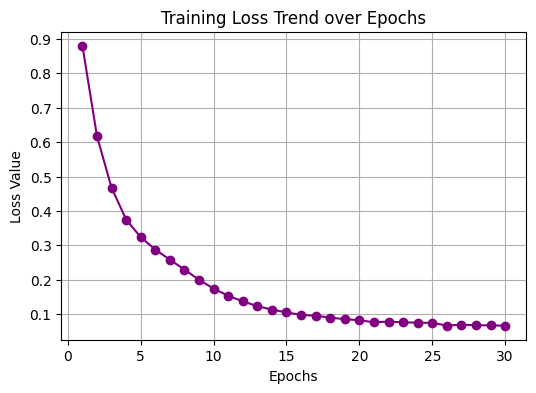


--- Classification Matrix Report ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [16]:
model.eval()
with torch.no_grad():
    # Pass all raw test inputs through the network
    raw_outputs = model(X_test_tensor)
    # The actual predicted class is the index with the highest probability value
    _, predicted_classes = torch.max(raw_outputs, 1)

# Visualizing Training Loss Curve over time
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='purple')
plt.title('Training Loss Trend over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.grid(True)
plt.show()

# Generate complete metrics output
print("\n--- Classification Matrix Report ---")
print(classification_report(y_test, predicted_classes.numpy(), target_names=encoder.classes_))

In [17]:
pip install torch pandas numpy matplotlib scikit-learn

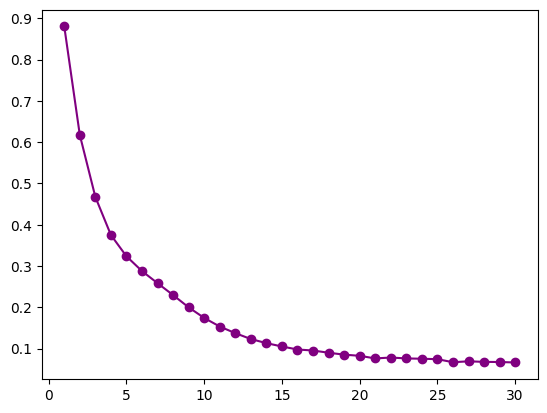

In [18]:
# To regenerate loss metrics profile curves inside the environment, execute:
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='purple')
plt.show()